In [0]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_score , silhouette_samples
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
spotify_user_behavior =spark.table("spotify.spotify_user_behavior").toPandas()
CLUSTER_FEATURES_V1=[
    "daily_listening_minutes",
    "sessions_per_day",
    "days_active_last_30",
    "avg_session_minutes",
    "skip_rate",
    "liked_songs_pct",
    "ads_skipped_pct",
]

iteration 8 results |k={K}
inertia: 471012.28
silhoutte: 0.166
cluster profile(means,original scale) - Iteration 6 (PowerTransformer labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
17925,86.61048817384024,2.687,21.964757185857124,32.397983758099784,0.289,0.30651889125587223,0.579770517621438
37460,14.973016377744084,1.08,20.362217632082945,14.510435281627359,0.411,0.24786355571743374,0.48386585318339165
26899,45.741404622040605,1.0,24.744633491183652,45.741404622040605,0.285,0.3930298131557334,0.4828126422595701
25716,46.639261933723,1.0,18.060951615033378,46.63598136376379,0.269,0.21611907565971603,0.6698472337614557


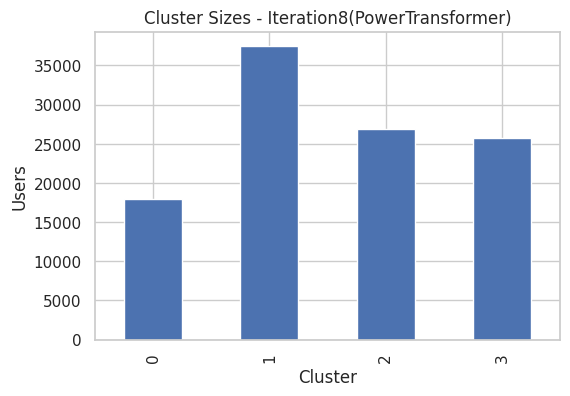

In [0]:
base = spotify_user_behavior[["user_id"]+CLUSTER_FEATURES_V1].copy()
K=4
X8=base[CLUSTER_FEATURES_V1].copy()
pt=PowerTransformer(method="box-cox", standardize=False)
Power=PowerTransformer()
X8_Power=Power.fit_transform(X8)
X8=pd.DataFrame(X8_Power,columns=CLUSTER_FEATURES_V1,index=base.index)
km8=KMeans(n_clusters=K,random_state=42,n_init=20,max_iter=300)
labels8=km8.fit_predict(X8)
inertia8=km8.inertia_
sil_avg8=silhouette_score(X8,labels8)
base_iter8=base.copy()
base_iter8["cluster"]=labels8
print("iteration 8 results |k={K}")
print("inertia:",round(inertia8,2))
print("silhoutte:",round(sil_avg8,3))
sizes8=base_iter8["cluster"].value_counts().sort_index()
means8=(
    base_iter8
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)
profile8=means8.copy()
profile8.insert(0,"cluster_size",sizes8)
print("cluster profile(means,original scale) - Iteration 6 (PowerTransformer labels):")
display(profile8)
plt.figure(figsize=(6,4))
base_iter8["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration8(PowerTransformer)")
plt.xlabel("Cluster")
plt.ylabel("Users")
plt.show()

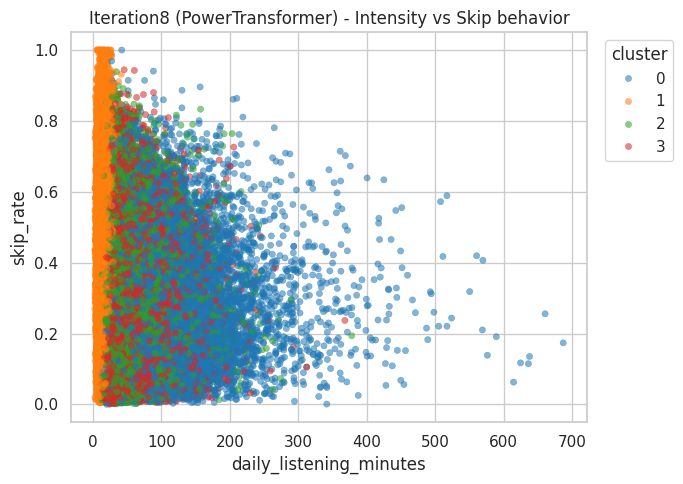

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter8,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration8 (PowerTransformer) - Intensity vs Skip behavior")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()



    


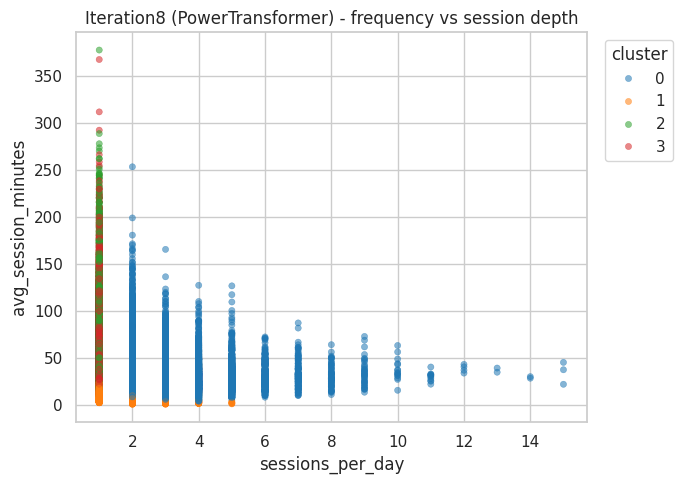

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter8,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration8 (PowerTransformer) - frequency vs session depth")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()

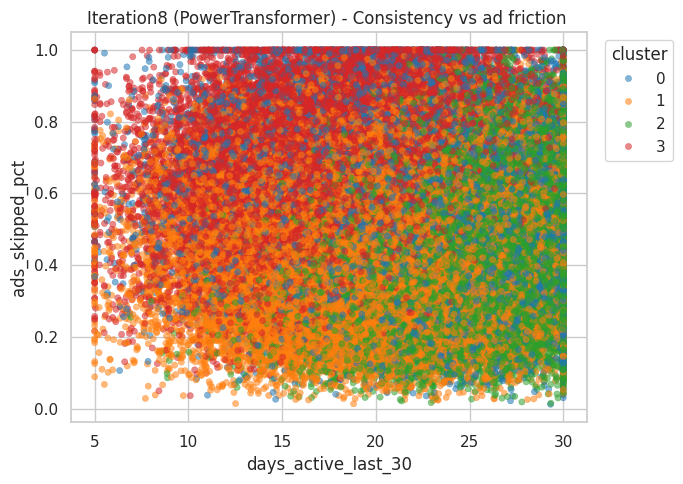

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter8,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration8 (PowerTransformer) - Consistency vs ad friction ")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()



    


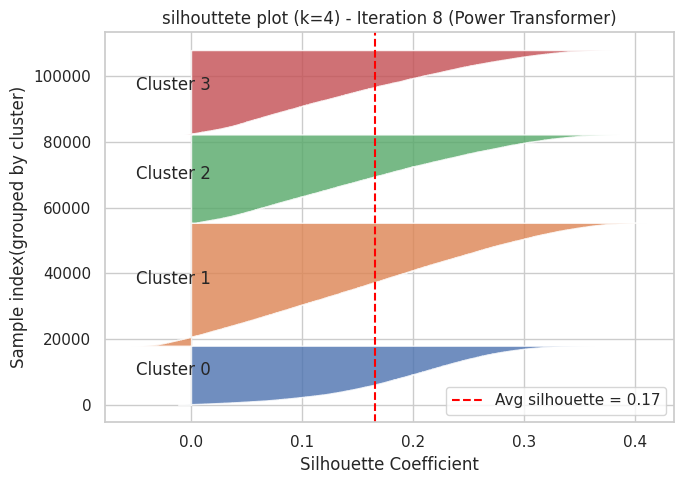

In [0]:
sil_values_8=silhouette_samples(X8,labels8)
plt.figure(figsize=(7,5))
y_lower=0
vals0=sil_values_8[labels8==0]
vals0.sort()
size0=vals0.shape[0]
y_upper=y_lower+size0
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals0,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size0,
    "Cluster 0"
)
y_lower=y_upper

vals1=sil_values_8[labels8==1]
vals1.sort()
size1=vals1.shape[0]
y_upper=y_lower+size1
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals1,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size1,
    "Cluster 1"
)
y_lower=y_upper

vals2=sil_values_8[labels8==2]
vals2.sort()    
size2=vals2.shape[0]
y_upper=y_lower+size2
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals2,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size2,
    "Cluster 2"
)
y_lower=y_upper    

vals3=sil_values_8[labels8==3]
vals3.sort()    
size3=vals3.shape[0]
y_upper=y_lower+size3
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals3,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size2,
    "Cluster 3"
)
y_lower=y_upper   
plt.axvline(
    x=sil_avg8,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sil_avg8:.2f}"
)
plt.title("silhouttete plot (k=4) - Iteration 8 (Power Transformer)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

In [0]:
print("iteration  8 avg Silhoutte:",round(sil_avg8,3))

iteration  8 avg Silhoutte: 0.166
